In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing  import StandardScaler
from sklearn.cluster        import KMeans
from sklearn.metrics        import silhouette_score
from sklearn.decomposition  import PCA


# (i)  READ DATASET INTO DATAFRAME
df = pd.read_csv('customer_behavior.csv')
print(" Dataset Loaded\n")
print(df.head(10).to_string(index=False))
print(f"\n  Shape   : {df.shape}")
print(f"  Columns : {list(df.columns)}")
print("\n  Statistical Summary:")
print(df.describe().round(2))

 Dataset Loaded

 age  annual_income  monthly_spend  purchase_freq  loyalty_score  online_pct  num_products  avg_rating
  62          18893           1823              6           0.28           8             3         4.2
  57          24340           1268              1           0.32           0             1         3.5
  54          22513           1045              1           0.42           8             1         3.1
  57          20887            924              3           0.25           7             1         4.7
  59          11538           1911              1           0.32           0             1         3.9
  63          21370           1442              1           0.18           4             1         4.3
  61           5895           1662              1           0.25          14             2         4.3
  55          17526           1665              4           0.26           8             1         3.2
  64          30849           1463              5       

In [2]:
# (ii)  DATA PREPROCESSING & FEATURE SCALING
print(" Preprocessing & Feature Scaling")
# Check for nulls
print(f"\n  Null values:\n{df.isnull().sum().to_string()}")

# All columns are numeric — scale with StandardScaler
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)
print("\n  After Standardization (mean≈0, std≈1):")
print(X_scaled.describe().round(3))

 Preprocessing & Feature Scaling

  Null values:
age              0
annual_income    0
monthly_spend    0
purchase_freq    0
loyalty_score    0
online_pct       0
num_products     0
avg_rating       0

  After Standardization (mean≈0, std≈1):
           age  annual_income  monthly_spend  purchase_freq  loyalty_score  \
count  200.000        200.000        200.000        200.000        200.000   
mean    -0.000          0.000         -0.000         -0.000          0.000   
std      1.003          1.003          1.003          1.003          1.003   
min     -1.734         -1.847         -1.825         -1.536         -2.219   
25%     -0.901         -0.717         -0.886         -0.803         -0.699   
50%     -0.102          0.039          0.034          0.114          0.111   
75%      0.974          0.829          0.934          0.663          0.736   
max      1.668          1.791          1.547          2.313          2.043   

       online_pct  num_products  avg_rating  
count   

In [3]:
# (iii) APPLY K-MEANS FOR DIFFERENT VALUES OF K

print("K-Means for K = 2 to 10")

k_range    = range(2, 11)
inertias   = []          # within-cluster sum of squares (WCSS)
sil_scores = []          # silhouette scores

print(f"\n  {'K':<6} {'Inertia (WCSS)':>18} {'Silhouette Score':>18}")
print("  " + "-" * 44)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia = km.inertia_
    sil     = silhouette_score(X_scaled, km.labels_)
    inertias.append(inertia)
    sil_scores.append(sil)
    print(f"  {k:<6} {inertia:>18.2f} {sil:>18.4f}")

K-Means for K = 2 to 10

  K          Inertia (WCSS)   Silhouette Score
  --------------------------------------------
  2                  757.17             0.4372
  3                  525.89             0.4002
  4                  378.88             0.4103
  5                  342.65             0.3720
  6                  306.79             0.3422
  7                  276.45             0.3158
  8                  244.88             0.2735
  9                  230.85             0.2663
  10                 219.55             0.2501


In [4]:
# (iv)  ELBOW METHOD — find optimal K

# Find elbow: biggest drop in inertia reduction
diffs       = np.diff(inertias)
diffs2      = np.diff(diffs)
elbow_k     = int(k_range[np.argmax(diffs2) + 2])   # +2 offset from double diff

print(" Elbow Method — Optimal K")
print(f"  Inertia drops:  {[round(d,1) for d in diffs]}")
print(f"   Optimal K from Elbow Method : {elbow_k}")

 Elbow Method — Optimal K
  Inertia drops:  [np.float64(-231.3), np.float64(-147.0), np.float64(-36.2), np.float64(-35.9), np.float64(-30.3), np.float64(-31.6), np.float64(-14.0), np.float64(-11.3)]
   Optimal K from Elbow Method : 5


In [5]:
# (v)  SILHOUETTE SCORE VALIDATION

best_sil_k = int(k_range[np.argmax(sil_scores)])

print(" Silhouette Score Validation")
print(f"  Best Silhouette Score : {max(sil_scores):.4f}  at K = {best_sil_k}")
print(f"  (Score range: -1 to 1 — closer to 1 is better)")

# Final K — prefer silhouette if they agree, else use elbow
optimal_k = best_sil_k
print(f"\n   Final Chosen K = {optimal_k}  (based on Silhouette Score)")

 Silhouette Score Validation
  Best Silhouette Score : 0.4372  at K = 2
  (Score range: -1 to 1 — closer to 1 is better)

   Final Chosen K = 2  (based on Silhouette Score)


In [6]:
# (vi)  FINAL CLUSTERING WITH OPTIMAL K
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

print(f" Clustering with K = {optimal_k}")

print("\n  Cluster Assignments (first 10 rows):")
print(df.head(10).to_string(index=False))

print("\n  Cluster Sizes:")
print(df['Cluster'].value_counts().sort_index().to_string())

# Cluster profiles — mean of each feature per cluster
cluster_profile = df.groupby('Cluster').mean().round(2)
print("\n  Cluster Profiles (mean values per cluster):")
print(cluster_profile.to_string())

# Give each cluster a name based on spending/income
print("\n  Cluster Interpretation:")
labels_map = {}
profile_sorted = cluster_profile.sort_values('monthly_spend')
for rank, (cid, row) in enumerate(profile_sorted.iterrows()):
    if rank == 0:
        name = " Budget Shoppers"
    elif rank == optimal_k - 1:
        name = " Premium Customers"
    elif row['annual_income'] > cluster_profile['annual_income'].median():
        name = " Affluent Regulars"
    else:
        name = " Mid-tier Buyers"
    labels_map[cid] = name
    print(f"  Cluster {cid} → {name}"
          f"  (avg spend=₹{row['monthly_spend']:,.0f}, "
          f"income=₹{row['annual_income']:,.0f})")

 Clustering with K = 2

  Cluster Assignments (first 10 rows):
 age  annual_income  monthly_spend  purchase_freq  loyalty_score  online_pct  num_products  avg_rating  Cluster
  62          18893           1823              6           0.28           8             3         4.2        0
  57          24340           1268              1           0.32           0             1         3.5        0
  54          22513           1045              1           0.42           8             1         3.1        0
  57          20887            924              3           0.25           7             1         4.7        0
  59          11538           1911              1           0.32           0             1         3.9        0
  63          21370           1442              1           0.18           4             1         4.3        0
  61           5895           1662              1           0.25          14             2         4.3        0
  55          17526           1665       

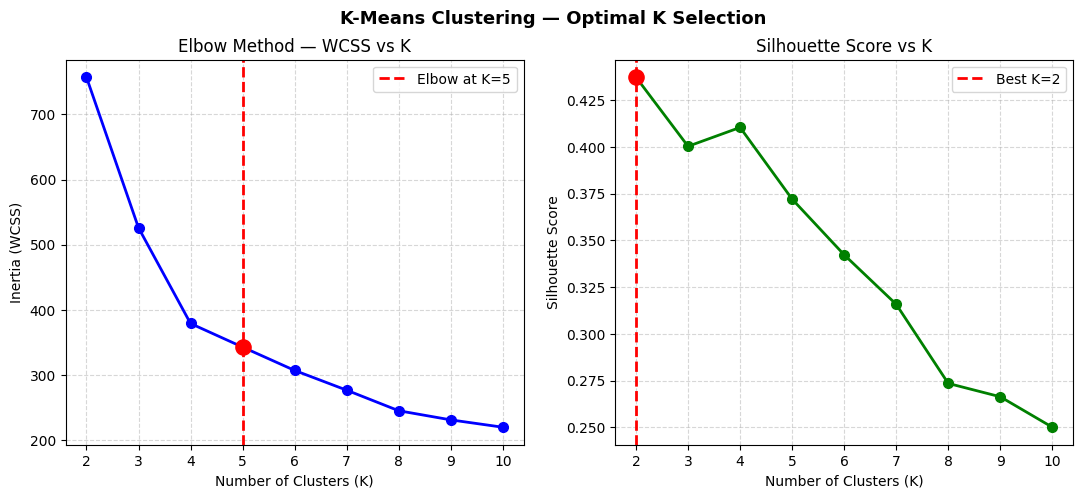

In [7]:
# (vii)  VISUALIZATIONS
cluster_colors = ['steelblue', 'salmon', 'mediumseagreen','orange', 'purple', 'brown'][:optimal_k]

# PLOT 1 : Elbow Curve + Silhouette Score

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('K-Means Clustering — Optimal K Selection',fontsize=13, fontweight='bold')

k_list = list(k_range)

axes[0].plot(k_list, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].axvline(elbow_k, color='red', linestyle='--', linewidth=2,label=f'Elbow at K={elbow_k}')
axes[0].scatter([elbow_k], [inertias[elbow_k - 2]], color='red', s=120, zorder=5)
axes[0].set_title('Elbow Method — WCSS vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(k_list, sil_scores, 'go-', linewidth=2, markersize=7)
axes[1].axvline(best_sil_k, color='red', linestyle='--', linewidth=2, label=f'Best K={best_sil_k}')
axes[1].scatter([best_sil_k], [max(sil_scores)], color='red', s=120, zorder=5)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)

C:\Users\kSaty\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


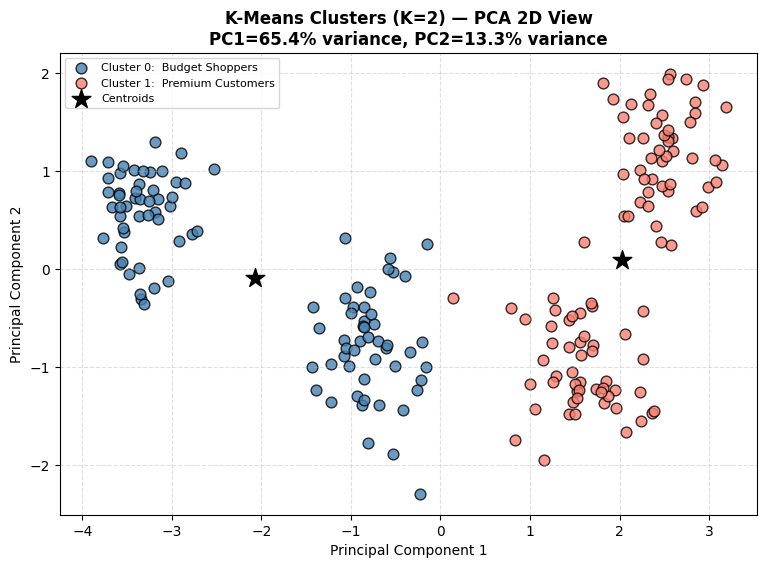

In [9]:
# PLOT 2 : Clusters in 2D using PCA
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_scaled)
var_exp= pca.explained_variance_ratio_
plt.figure(figsize=(9, 6))
for cid in range(optimal_k):
    mask = df['Cluster'] == cid
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=cluster_colors[cid], label=f'Cluster {cid}: {labels_map[cid]}',edgecolors='black', s=60, alpha=0.8)

# Plot centroids in PCA space
centroids_pca = pca.transform(km_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='*', s=200, zorder=5, label='Centroids')

plt.title(f'K-Means Clusters (K={optimal_k}) — PCA 2D View\n'
          f'PC1={var_exp[0]*100:.1f}% variance, '
          f'PC2={var_exp[1]*100:.1f}% variance',
          fontsize=12, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(fontsize=8, loc='best')
plt.grid(True, linestyle='--', alpha=0.4)

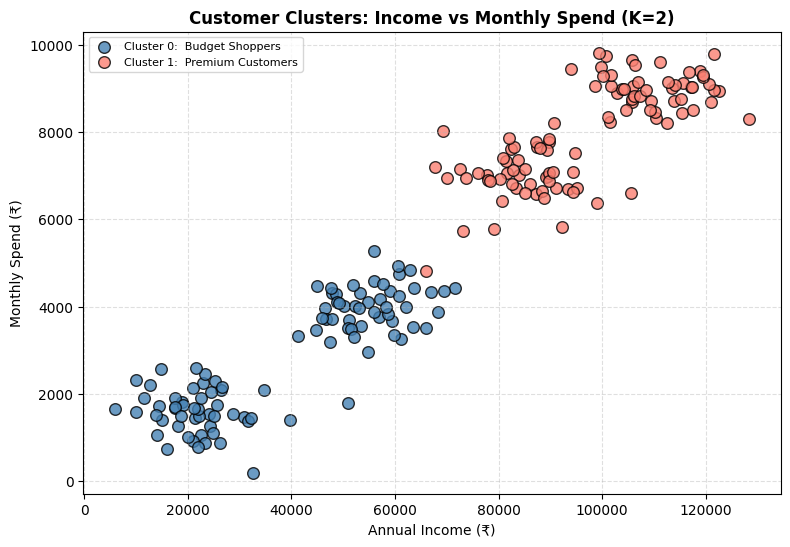

In [10]:
# PLOT 3 : Income vs Monthly Spend — coloured by cluster

plt.figure(figsize=(9, 6))
for cid in range(optimal_k):
    mask = df['Cluster'] == cid
    plt.scatter(df[mask]['annual_income'],df[mask]['monthly_spend'],c=cluster_colors[cid],
                label=f'Cluster {cid}: {labels_map[cid]}',edgecolors='black', s=70, alpha=0.8)
plt.title(f'Customer Clusters: Income vs Monthly Spend (K={optimal_k})',fontsize=12, fontweight='bold')
plt.xlabel('Annual Income (₹)')
plt.ylabel('Monthly Spend (₹)')
plt.legend(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.4)

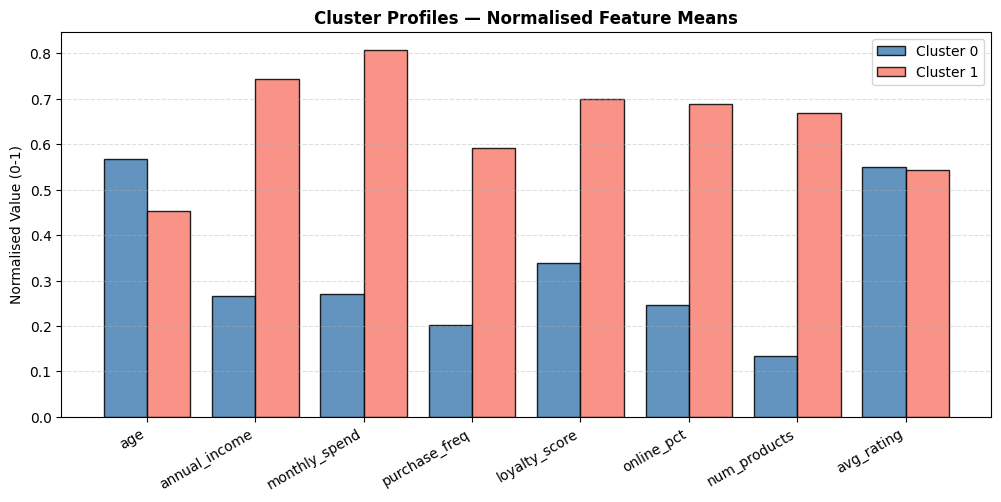

In [14]:
# PLOT 4 : Cluster Profile Radar / Bar Chart

feat_cols = [c for c in df.columns if c != 'Cluster']
profile   = df.groupby('Cluster')[feat_cols].mean()

x    = np.arange(len(feat_cols))
w    = 0.8 / optimal_k

fig, ax = plt.subplots(figsize=(12, 5))
for i, cid in enumerate(range(optimal_k)):
    norm_vals = (profile.loc[cid] - df[feat_cols].min()) / \
                (df[feat_cols].max() - df[feat_cols].min())
    ax.bar(x + i*w - (optimal_k-1)*w/2, norm_vals, width=w, color=cluster_colors[i], edgecolor='black',alpha=0.85, label=f'Cluster {cid}')

ax.set_title('Cluster Profiles — Normalised Feature Means', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(feat_cols, rotation=30, ha='right')
ax.set_ylabel('Normalised Value (0-1)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

In [15]:
#  SUMMARY
print(" SUMMARY")
print(f"  Dataset          : 200 customers, 8 features")
print(f"  Optimal K        : {optimal_k}  (Elbow={elbow_k}, Silhouette best={best_sil_k})")
print(f"  Silhouette Score : {max(sil_scores):.4f}")
print(f"\n  Cluster Breakdown:")
for cid in range(optimal_k):
    size = (df['Cluster'] == cid).sum()
    print(f"    Cluster {cid} → {labels_map[cid]:<25}  ({size} customers)")
print(f"\n   Key Observations:")
print(f"  1. Clusters show distinct income-spend patterns.")
print(f"  2. High loyalty customers are concentrated in premium cluster.")
print(f"  3. Online purchase % varies significantly across clusters.")
print(f"  4. Budget shoppers have low frequency and low spend.")

 SUMMARY
  Dataset          : 200 customers, 8 features
  Optimal K        : 2  (Elbow=5, Silhouette best=2)
  Silhouette Score : 0.4372

  Cluster Breakdown:
    Cluster 0 →  Budget Shoppers           (99 customers)
    Cluster 1 →  Premium Customers         (101 customers)

   Key Observations:
  1. Clusters show distinct income-spend patterns.
  2. High loyalty customers are concentrated in premium cluster.
  3. Online purchase % varies significantly across clusters.
  4. Budget shoppers have low frequency and low spend.
